# The Fourth Circle: Neural Networks, Part Four 
## Transformers I: Bahdanau Attention

<br/>
Jiří Fejlek

2026-04-12
<br/>


## Table of Contents

- [Tatoeba Project Dataset](#tatoeba)
- [Attention](#attention)
    - [Kernel Density Estimator and Kernel Regression](#kde)
    - [Scaled Dot-Product Attention](#dot_product)
    - [Additive Attention](#additive)
- [Bahdanau Attention Mechanism](#bahdanau)
    - [Computations inside the Bahdanau Attention Step by Step](#step)
- [Training Encoder-Decoder Model with the Bahdanau Attention](#train)
- [References](#references)

  
In the fourth part of this cycle, dedicated to various neural network architectures, we will finally cover the architecture that has essentially dominated the field of machine learning to this point: the transformer architecture. Here, we start with a core element of transformers, the *attention mechanism*, introduced in 2014 [[1](#1)]. The attention mechanism was originally proposed as an improvement to the RNN-based encoder-decoder architecture to alleviate its major limitation: the encoder produces a single *fixed-length* representation of the input for the decoder, regardless of the length of the input [[1](#1)].

The main idea behind the attention mechanism is that the decoder no longer receives a fixed representation of the input sequence (a so-called *context*). Instead, the context, computed as a weighted sum of the encoder outputs, dynamically changes as the decoder produces output. This enables the decoder to focus on different parts of the input sequence at each decoding step [[1](#1)].


## Tatoeba Project Dataset <a class="anchor" id="tatoeba"></a>

Before we move to the introduction of the attention mechanism, we will repeat the implementation of the processing steps for the dataset of  bilingual sentence pairs from https://www.manythings.org/anki/ based on the Tatoeba project https://tatoeba.org/en.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import math

import torchvision
import torch

from torch import nn
from torch.utils.data import DataLoader
import torch.nn.functional as F

import re
import collections
import os

np.set_printoptions(legacy='1.25')

In [2]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 4070 Ti'

In [3]:
def _preprocess(text):
    no_space = lambda char, prev_char: char in ',.!?' and prev_char != ' '
    out = [' ' + char if i > 0 and no_space(char, text[i - 1]) else char
           for i, char in enumerate(text.lower())]
    return ''.join(out)

In [4]:
class Vocabulary: 

    def __init__(self, tokens=[], min_freq=0, reserved_tokens=[]):
        
        # Flatten the list of tokens
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        
        # Count token frequencies
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse = True)

        # The list of unique tokens, we ignore tokens with frequency lower than min_freq
        self.idx_to_token = list(sorted(set(['<unk>'] + reserved_tokens + [token for token, freq in self.token_freqs if freq >= min_freq]))) 
        # convert tokens to indices
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}
     
    def __len__(self):
        return len(self.idx_to_token)
    
    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk) # return unknown token if not in the vocabulary
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.idx_to_token[int(index)] for index in indices]
        return self.idx_to_token[indices]
    
    @property
    def unk(self): # index for the unknown token
        return self.token_to_idx['<unk>']

In [5]:
class Tatoeba:

    def _preprocess(self, text):
        
        # Insert space between words and punctuation marks
        no_space = lambda char, prev_char: char in ',.!?' and prev_char != ' '
        out = [' ' + char if i > 0 and no_space(char, text[i - 1]) else char
               
               for i, char in enumerate(text.lower())]
        
        return ''.join(out)

    def truncate_pad(self, line, num_steps, padding_token):
        if len(line) > num_steps:
            return line[:num_steps]  # Truncate
        return line + [padding_token] * (num_steps - len(line))  # Pad
    
    def _read(self):
        
        data_dir = self.data_dir
        tatoeba_data = []
        
        with open(data_dir, encoding='utf-8') as file:
            lines = [line.rstrip() for line in file]

        for line in lines:
            line = _preprocess(line)
            idx = line.find("cc-by")
            tatoeba_data.append(line[:idx-1])
        
        lang1_text = []
        lang2_text = []
        
        for lines in tatoeba_data:
            words = lines.split('\t')
            
            if len(words) == 2:
                
                lang1_line = [t for t in f'{words[0]} <eos>'.split(' ') if t]
                lang2_line = [t for t in f'<bos> {words[1]} <eos>'.split(' ') if t]
                
                if len(lang1_line) > self.max_length + 1:
                    del lang1_line[self.max_length:-1]
                    
                if len(lang2_line) > self.max_length + 2:
                    del lang2_line[self.max_length+1:-1]
                    
                lang1_text.append(lang1_line)
                lang2_text.append(lang2_line)

        self.lang1_text = lang1_text
        self.lang2_text = lang2_text

    def _build(self):
        
        self._read()
        self.vocab_lang_1 = Vocabulary(self.lang1_text, min_freq = 2, reserved_tokens= ['<pad>'])
        self.vocab_lang_2 = Vocabulary(self.lang2_text, min_freq = 2, reserved_tokens= ['<pad>'])

        corpus_lang_1 = [self.vocab_lang_1[token] for token in self.lang1_text]
        corpus_lang_2 = [self.vocab_lang_2[token] for token in self.lang2_text]

        len_1 = torch.zeros(len(corpus_lang_1))
        for i in range(len(corpus_lang_1)):
            len_1[i] = len(corpus_lang_1[i])

        self.len_1 = len_1.long() 
            

        len_2 = torch.zeros(len(corpus_lang_2))
        for i in range(len(corpus_lang_2)):
            len_2[i] = len(corpus_lang_2[i])
            
        self.len_2 = len_2.long() - 1

        self.corpus_lang_1 = [self.truncate_pad(line, self.max_length + 1, self.vocab_lang_1['<pad>']) for line in corpus_lang_1]
        self.corpus_lang_2 = [self.truncate_pad(line, self.max_length + 2, self.vocab_lang_2['<pad>']) for line in corpus_lang_2]

        
        np.random.seed(0)
        rand_perm = np.random.permutation(range(len(self.corpus_lang_1))) 

        corpus_lang_1_train = [self.corpus_lang_1[i] for i in rand_perm[:self.num_train]]
        corpus_lang_2_train = [self.corpus_lang_2[i] for i in rand_perm[:self.num_train]]
        len_1_train = [self.len_1[i] for i in rand_perm[:self.num_train]]
        len_2_train = [self.len_2[i] for i in rand_perm[:self.num_train]]

        corpus_lang_1_test = [self.corpus_lang_1[i] for i in rand_perm[self.num_train:]]
        corpus_lang_2_test = [self.corpus_lang_2[i] for i in rand_perm[self.num_train:]]
        len_1_test = [self.len_1[i] for i in rand_perm[self.num_train:]]
        len_2_test = [self.len_2[i] for i in rand_perm[self.num_train:]]

        dataset_train = torch.utils.data.TensorDataset(*[torch.tensor(corpus_lang_1_train), torch.tensor(corpus_lang_2_train),len_1_train, len_2_train])
        dataset_test = torch.utils.data.TensorDataset(*[torch.tensor(corpus_lang_1_test), torch.tensor(corpus_lang_2_test),len_1_test, len_2_test])

        self.train_dataloader = torch.utils.data.DataLoader(dataset_train, self.batch_size, shuffle = True)
        self.test_dataloader = torch.utils.data.DataLoader(dataset_test, self.batch_size, shuffle = False)  


               
    def __init__(self, data_dir, num_train, batch_size, max_length):
        
        self.data_dir = data_dir
        self.num_train = num_train
        self.batch_size = batch_size
        self.max_length = max_length

        self._build()

In [6]:
Tatoeba_dataset = Tatoeba('D:/nine circles 2/ces.txt', num_train = 38000, batch_size = 250, max_length = 15) 

for X, Y, X_len, Y_len in Tatoeba_dataset.train_dataloader:
    print('X:', X, '\nY:', Y, '\nX_len:', X_len, '\nY_len:', Y_len)
    break

X: tensor([[4658, 1188, 4565,  ...,   53,   53,   53],
        [5030, 1396, 2311,  ...,   53,   53,   53],
        [3374, 3948, 2806,  ...,   53,   53,   53],
        ...,
        [ 308, 5169, 3019,  ...,   53,   53,   53],
        [2156, 2674, 4514,  ...,   53,   53,   53],
        [2311, 4493, 5088,  ...,   53,   53,   53]]) 
Y: tensor([[  38, 7124,   41,  ...,   40,   40,   40],
        [  38,  583, 2587,  ...,   40,   40,   40],
        [  38, 5374, 7288,  ...,   40,   40,   40],
        ...,
        [  38, 7003, 1703,  ...,   40,   40,   40],
        [  38, 2623, 6103,  ...,   40,   40,   40],
        [  38, 2471, 1699,  ...,   40,   40,   40]]) 
X_len: tensor([ 9,  8,  7,  9,  6, 10, 10, 12,  6,  8,  9,  7,  6,  9,  8,  5,  7,  6,
         5,  7,  8,  8,  6,  9,  8, 15,  8,  6,  6,  6, 11,  6, 11, 12,  7,  6,
        10,  7,  7,  7,  6,  8,  7,  9,  9,  7, 14, 11,  9, 10, 16,  7,  5,  6,
         8,  4,  8,  7,  7,  8,  7,  7,  7,  4,  7,  6,  7, 10,  7,  6,  6,  9,
         7, 1

In [7]:
X[0]

tensor([4658, 1188, 4565,  745, 2440, 1536, 3337,   24,   52,   53,   53,   53,
          53,   53,   53,   53])

In [8]:
X[0][:X_len[0]]

tensor([4658, 1188, 4565,  745, 2440, 1536, 3337,   24,   52])

In [9]:
Y[0]

tensor([  38, 7124,   41,  838, 2715, 4379,   41,   17,   39,   40,   40,   40,
          40,   40,   40,   40,   40])

In [10]:
Y[0][1:][:Y_len[0]]

tensor([7124,   41,  838, 2715, 4379,   41,   17,   39])

## Attention <a class="anchor" id="attention"></a>

We first motivate the definition of attention [[2](#2)]. Let us define a *database* $\mathcal{D} = \{(k_1, v_1), \ldots, (k_n, v_n) \}$, which is a set of pairs $(k_i,v_i)$, where $k_i \in \mathbb{R}^{k_d}$ are *keys* and $v_i \in \mathbb{R}^{v_d}$ are *values*. Let us assume a *query* $q \in\mathbb{R}^{q_d}$ for the database $\mathcal{D}$, the attention for the query $q$ is defined as
$$ \text{Attention}(\mathcal{D},q) = \sum_{i = 1}^n \alpha(q, k_i)v_i,$$
where $\alpha(q, k_i) \in \mathbb{R}$ are *attention weights*, which represent the similarity between the keys and the query. Consequently, in general, the attention for a given query is a linear combination of the values in the database. Provided that we set $\alpha(q, k_i) = 1$ whenever $q = k_i$ and $0$ otherwise, we obtain a traditional database query.

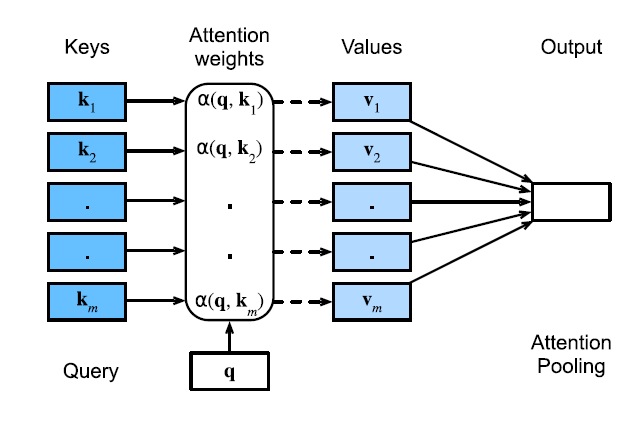

### Kernel Density Estimator and Kernel Regression<a class="anchor" id="kde"></a>

Let us demonstrate the application of the attention mechanism in the context of stastical modeling. We start with the kernel density estimator (KDE). Let us assume a random sample $(x_1, ..., x_n)$ from a continuous distribution with a density $f$. We wish to estimate this density nonparametrically. A standard approach that we use all the time, mostly for visual purposes, is a histogram. 

In [11]:
np_size = 50000
# generate a sample from a mixture of two normal distributions
u = np.random.uniform(low = 0.0, high=1.0, size = np_size)
X = (1-np.round(u))*np.random.normal(loc = 1.15, scale= 1, size=np_size) + np.round(u)*np.random.normal(loc = -1.15, scale= 1, size=np_size)

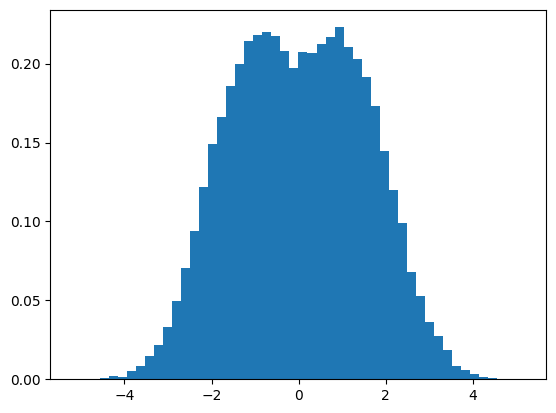

In [12]:
plt.hist(X,bins = 50, density = True);

When we construct a histogram, we turn a continuous random variable into a discrete one by partitioning the values into bins. However, the main issue with this approach is that, although the histogram's shape depends heavily on the choice of bins, this selection is largely arbitrary and it is not immediately obvious how to get "optimal" results.

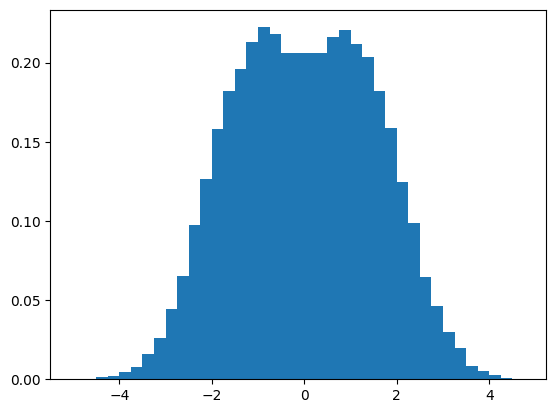

In [13]:
plt.hist(X,bins = np.hstack([np.arange(-5, -0.25, 0.25), np.arange(0.5, 5.0, 0.25)]), density = True);

Hence, we can instead consider a *kernel density estimator*, which can be computed as [[3](#3)]
$$ f(x) = \frac{1}{n}\sum_{i = 1}^n K_h (x - x_i) = \frac{1}{nh}\sum_{i = 1}^d K \left(\frac{x-x_i}{h}\right),$$
where $K$ is a kernel such as the Gaussian kernel $K(y) = \frac{1}{\sqrt{2\pi}}\text{exp }\left(-\frac{1}{2} y^2\right)$ or Epanechnikov kernel $K(y) = \frac{3}{4}(1-u^2)$.

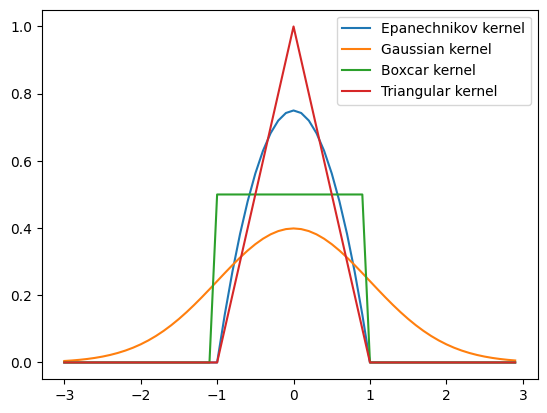

In [14]:
def epanechnikov(x):
    return 3/4*(1-x**2)*(np.abs(x)<1)
    
def gaussian(x):
    return np.exp(-x**2 / 2)/(np.sqrt(2*np.pi))

def boxcar(x):
    return (np.abs(x)<1)*1/2
    
def triangular(x):
    return (1-np.abs(x))*(np.abs(x)<1)
    
x = np.arange(-3, 3, 0.1)
plt.plot(x, epanechnikov(x), label= "Epanechnikov kernel")
plt.plot(x, gaussian(x), label= "Gaussian kernel");
plt.plot(x, boxcar(x), label= "Boxcar kernel");
plt.plot(x, triangular(x), label= "Triangular kernel");
plt.legend(loc="upper right");

We can easily notice that the kernel density estimator corresponds to our definition of the attention, provided that we set $\alpha(q,k_i) = \frac{1}{nh}K\left(\frac{q-k_i}{h}\right)$ and $v_i = 1$. The keys of the database $k_i$ are the samples $x_i$, and the values in which we wish to evaluate the estimated density $x$ correspond to queries $q$. By the way, we can compute the kernel density estimator using *sklearn* as follows.

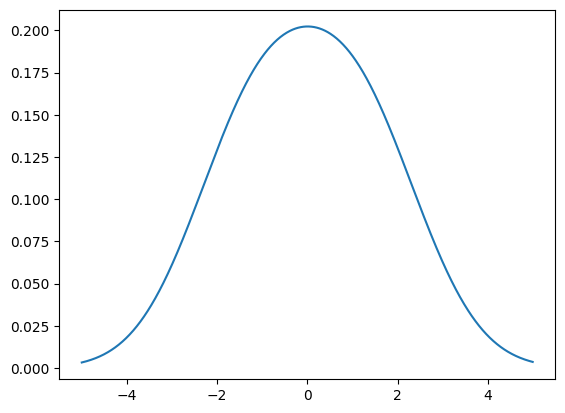

In [15]:
from sklearn.neighbors import KernelDensity
kde = KernelDensity(kernel='gaussian', bandwidth = 1).fit(X.reshape(-1, 1))

x = np.arange(-5, 5, 0.01)
log_density  = kde.score_samples(x.reshape(-1, 1))
plt.plot(x.reshape(-1, 1),np.exp(log_density));

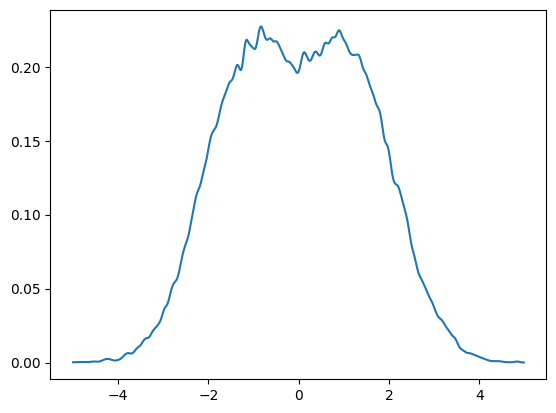

In [16]:
kde = KernelDensity(kernel = 'gaussian', bandwidth = 0.05).fit(X.reshape(-1, 1))

x = np.arange(-5, 5, 0.01)
log_density  = kde.score_samples(x.reshape(-1, 1))
plt.plot(x.reshape(-1, 1), np.exp(log_density));

We observe that the resulting estimate depends on the bandwidth parameter $h$. We can estimate the optimal value from the data using cross-validation, selecting the log-likelihood on the test samples as our metric.

In [17]:
from sklearn.model_selection import KFold

bandwidth = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]

np.random.seed(123)

folds = 5
loglik_cv =  np.zeros([len(bandwidth), folds])

kf = KFold(n_splits = folds) # create folds

for i in range(len(bandwidth)):
    idx_cv = np.random.choice([*range(0,len(X))],len(X), replace=False) 
    
    for j, (train_index, test_index) in enumerate(kf.split(idx_cv)):
        
        train_set = idx_cv[train_index]
        test_set = idx_cv[test_index]

        X_train = X[train_set]
        X_test = X[test_set]

        kde_new = KernelDensity(kernel='gaussian', bandwidth = bandwidth[i]).fit(X_train.reshape(-1, 1))
        loglik_cv[i,j] = kde_new.score_samples(X_test.reshape(-1, 1)).mean()
        

In [18]:
pd.DataFrame(loglik_cv.mean(1), index = bandwidth, columns = ['log-lik'])

,log-lik
0.001,-3.626640
0.005,-1.979358
0.010,-1.838863
0.050,-1.819887
0.100,-1.819042
0.500,-1.824210
1.000,-1.863990


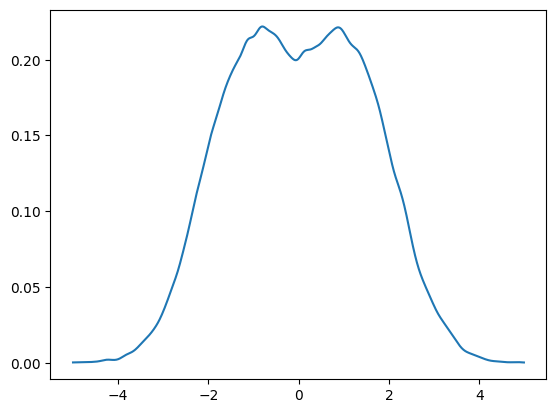

In [19]:
kde = KernelDensity(kernel = 'gaussian', bandwidth = 0.1).fit(X.reshape(-1, 1))
x = np.arange(-5, 5, 0.01)
log_density  = kde.score_samples(x.reshape(-1, 1))
plt.plot(x.reshape(-1, 1), np.exp(log_density));

We can use a similar estimator even for regression tasks $\text{E }(Y\mid X) = m(x)$. Namely, the kernel regression estimate (Nadaraya–Watson estimator) [[3](#3)] is
$$ \hat m(x) =  \frac{\sum_{i = 1}^n K_h (x - x_i) y}{\sum_{i = 1}^n K_h (x - x_i)}.$$
We should note that the Nadaraya–Watson estimator can be derived from the kernel density estimators; we apply the kernel density estimator on $\hat f(x) = \frac{1}{n}\sum_{i = 1}^d K_h (x - x_i)$ and $\hat f(x,y) = \frac{1}{n}\sum_{i = 1}^d K_h (x - x_i) K_h (y - y_i)$ and use the fact that $f(y\mid x) = f(x,y)/f(x).$ Lastly, we will compute $\text{E }(Y\mid X) = \int y f(y\mid x) \mathrm{d}y$.

Let us demonstrate kernel regression, which is implemented in Python in *statsmodels*.

In [20]:
def f(x):
    return 2*np.sin(x) + x
    
n = 500
x_train = np.sort(np.random.uniform(size = n) * 10)
y_train = f(x_train) + np.random.normal(size = n)

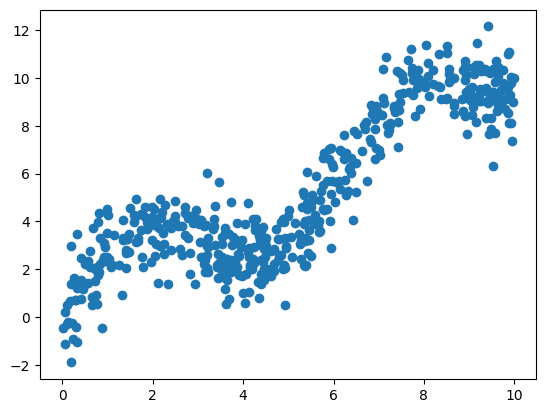

In [21]:
plt.scatter(x_train, y_train);

In [22]:
import statsmodels
import statsmodels.api as sm

# lc stands for local constant, which corresponds to Nadaraya–Watson estimator
nw_est = statsmodels.nonparametric.kernel_regression.KernelReg(endog = y_train, exog = x_train, var_type  = 'c', ckertype = 'gaussian', reg_type = 'lc', bw = [0.1])

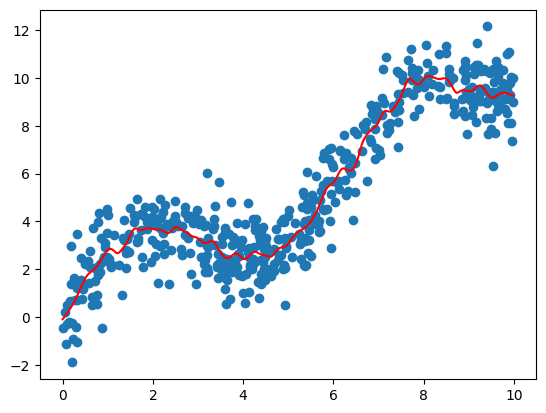

In [23]:
x = np.arange(0, 10, 0.01)
pred_x = nw_est.fit(x)[0]

plt.scatter(x_train, y_train)
plt.plot(x,pred_x, 'r-');

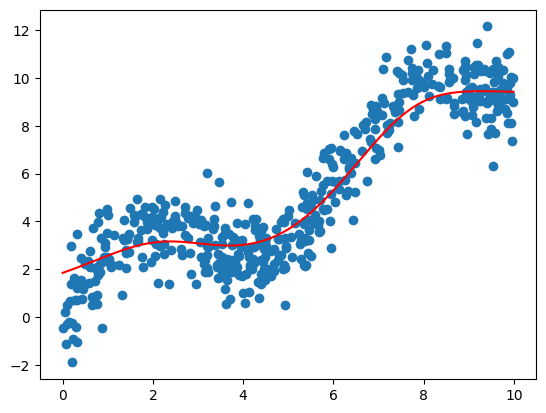

In [24]:
nw_est = statsmodels.nonparametric.kernel_regression.KernelReg(endog = y_train, exog = x_train, var_type  = 'c', ckertype = 'gaussian', reg_type = 'lc', bw = [1])
x = np.arange(0, 10, 0.01)
pred_x = nw_est.fit(x)[0]

plt.scatter(x_train, y_train)
plt.plot(x,pred_x, 'r-');

Again, we need to select the appropriate bandwidth. Similar to kernel density estimation, we can use cross-validation by setting *bw = 'cv_ls'*. 

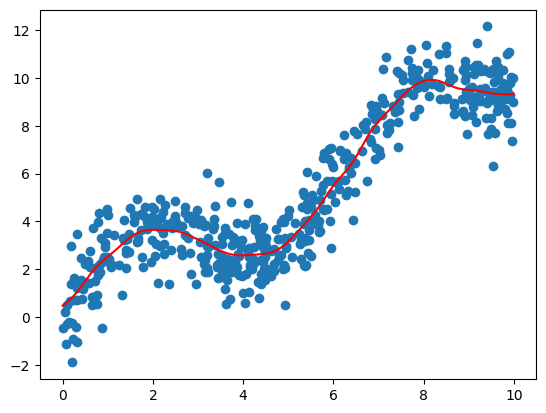

In [25]:
nw_est = statsmodels.nonparametric.kernel_regression.KernelReg(endog = y_train, exog = x_train, var_type  = 'c', ckertype = 'gaussian', reg_type = 'lc', bw = 'cv_ls')
x = np.arange(0, 10, 0.01)
pred_x = nw_est.fit(x)[0]

plt.scatter(x_train, y_train)
plt.plot(x,pred_x, 'r-');

Using the attention terminology on the Nadaraya–Watson estimator, the values of the dependent variable now correspond to the values, i.e., $v_i = y_i$, and the attention weights are $\alpha(q,k_i) = \frac{K_h (q - k_i)}{\sum_{i = 1}^d K_h (q - k_i)}$.

Overall, we observe that the attention mechanism is a powerful tool for statistical modeling, both for density estimation/classification (classification problems lead to estimating class probabilities, i.e., class-specific probability densities) and for regression. 

### Scaled Dot-Product Attention <a class="anchor" id="dot_product"></a>

In the previous section, we observed various kernel-based attention weights. In neural network architectures, one of the most popular attention mechanisms, due to its simplicity and computational efficiency, is the scaled dot-product attention, which is further normalized by a softmax layer. Let us assume that $q \in \mathbb{R}^{q_d}$ and $k_i \in \mathbb{R}^{k_d}$ such that $q_d = k_d = d$, then the scale dot-product attention is  [[2](#2)]
$$ \alpha(q,k_i) = \frac{\text{exp}(a(q,k_i))}{\sum_j \text{exp}(a(q,k_j))},$$
where $$ a(q,k_i) = \frac{q^Tk_i}{\sqrt{d}}.$$

The scaling factor $1/\sqrt{d}$ is motivated by the fact that, provided that all elements of a query $q$ and a key $k_i$ are independently distributed with zero expectation and unit variance, then $q^Tk_i$ has variance $d$.

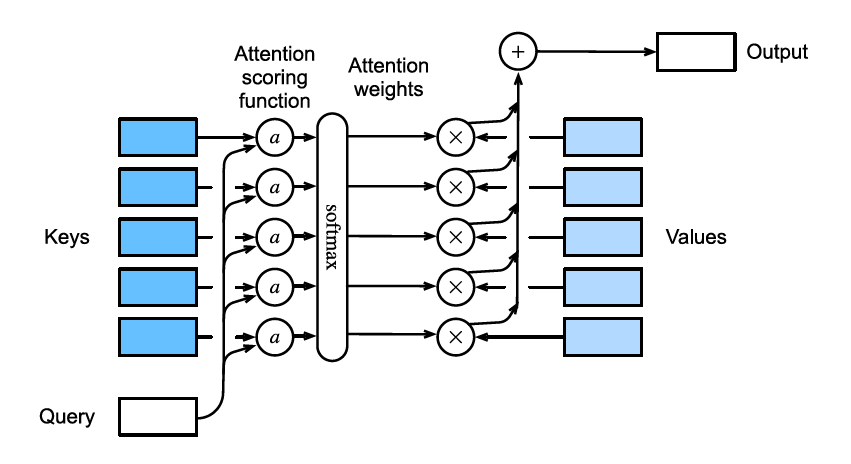

Let us implement the scaled dot-product attention. However, before we do that, we need to implement a custom softmax layer. As we will show a bit later, the encoder's outputs will serve as the keys and values of our "database". Hence, each key (and value) will equal the value of the hidden state of the last recurrent layer after the recurrent block reads the respective token of the input sequence. However, remember that, in general, the input sequences include padding (so that all sequences have the same length to enable easy parallelization), and we do not want padding tokens to influence the attention mechanism.  Hence, we want to limit the computation of attention $\sum_{i = 1}^n \alpha(q, k_i)v_i$ to the actual unpadded sequence length $l \leq n$.

We will use the implementation from [[2](#2)], which replaces the original input with a large negative value, ensuring that the corresponding softmax outputs are zero.

In [26]:
def masked_softmax(X, valid_lens): 
    
    def _sequence_mask(X, valid_len, value = 0):
        maxlen = X.size(1)
        mask = torch.arange((maxlen), dtype = torch.float32, device = X.device)[None, :] < valid_len[:, None]
        X[~mask] = value
        return X
        
    if valid_lens is None:
        return nn.functional.softmax(X, dim = -1)
    else:
        shape = X.shape
        
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)

        X = _sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
        return nn.functional.softmax(X.reshape(shape), dim=-1)

In [27]:
X = torch.rand(3, 2, 5)
X

tensor([[[0.4478, 0.2200, 0.1384, 0.5138, 0.0050],
         [0.2897, 0.3738, 0.7478, 0.7363, 0.8035]],

        [[0.4222, 0.0179, 0.7899, 0.5620, 0.7423],
         [0.3684, 0.4915, 0.8338, 0.0033, 0.7093]],

        [[0.3767, 0.7967, 0.4272, 0.2766, 0.8360],
         [0.9568, 0.1008, 0.4180, 0.0341, 0.1085]]])

In [28]:
masked_softmax(X, torch.tensor([1, 2, 3]))

tensor([[[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [1.0000, 0.0000, 0.0000, 0.0000, 0.0000]],

        [[0.5997, 0.4003, 0.0000, 0.0000, 0.0000],
         [0.4693, 0.5307, 0.0000, 0.0000, 0.0000]],

        [[0.2798, 0.4259, 0.2943, 0.0000, 0.0000],
         [0.4979, 0.2116, 0.2905, 0.0000, 0.0000]]])

We can now implement scaled dot-product attention itself. Let us assume the following queries, keys, and values (*batch_size* = 4, $n = 10$, $q_d = 5$, $k_d = 5$, $v_d = 3$).

In [29]:
queries = torch.normal(0, 1, (4, 1, 5))
queries

tensor([[[ 0.4530,  0.1406,  0.0973, -0.4533,  1.3788]],

        [[ 0.3604, -0.7010, -0.9335, -0.1934, -0.3256]],

        [[ 0.0452,  1.2476,  0.1188, -1.1887, -0.1484]],

        [[ 1.8413, -2.1756,  0.4154, -0.0409, -0.6305]]])

In [30]:
keys = torch.normal(0, 1, (4, 10, 5))
keys

tensor([[[-1.8484e+00, -6.1628e-01,  1.3268e+00,  1.6052e+00,  1.3563e+00],
         [ 1.2133e-01,  8.5833e-01,  1.1693e+00,  1.5689e+00,  4.3860e-01],
         [-9.8832e-01,  4.4847e-01,  2.5126e-01,  6.5823e-02,  5.1477e-01],
         [ 4.3212e-01, -8.1161e-01,  2.9185e+00,  1.3051e+00, -9.6166e-02],
         [-1.0012e+00, -5.1852e-01,  8.3166e-01,  1.1613e+00, -1.4155e-01],
         [-1.2152e+00,  1.2966e+00, -2.2234e-01,  7.0087e-02, -8.8323e-01],
         [-5.3067e-01, -9.8642e-01, -1.9736e-01, -8.4727e-01,  7.0280e-01],
         [ 8.2406e-01, -5.2626e-02,  6.6428e-01,  1.6952e+00, -5.7892e-01],
         [ 8.4674e-02, -5.4947e-01, -1.2017e+00, -1.2038e+00,  1.4253e-01],
         [-1.2010e+00, -9.8079e-01, -1.0694e-01, -1.5979e+00, -1.5863e-01]],

        [[ 2.8425e-02,  1.3608e+00,  6.6802e-02,  1.6008e+00, -9.2491e-01],
         [ 2.1854e-01,  2.1192e+00,  9.1582e-01,  1.7559e+00,  5.6746e-01],
         [-3.1559e-01,  4.2723e-01,  1.3729e+00,  1.1095e+00, -4.3068e-01],
         [

In [31]:
values = torch.normal(0, 1, (4, 10, 3))
values

tensor([[[ 2.4162e-01, -7.2650e-01,  1.1797e+00],
         [-3.1949e+00,  8.5333e-01, -1.5985e+00],
         [ 5.3125e-01, -1.3403e+00, -1.8661e-01],
         [-2.0763e+00,  1.8618e+00,  9.3937e-01],
         [ 2.8312e-01,  1.9270e-01, -9.1246e-01],
         [ 1.5400e+00, -2.3853e+00,  1.3945e+00],
         [-1.1404e+00, -2.6637e-02,  1.3394e-01],
         [-1.0610e+00, -5.4689e-01, -1.1782e+00],
         [-2.7398e-01,  5.6900e-01,  2.2150e+00],
         [ 1.8871e+00,  2.9259e-01, -2.7103e-02]],

        [[ 1.0676e+00,  1.6489e+00,  4.5469e-01],
         [-5.7354e-01,  4.3690e-01,  1.8326e+00],
         [ 3.0906e-01, -4.9832e-01, -1.4779e+00],
         [-9.6856e-01, -1.2795e+00, -8.2916e-01],
         [-3.4619e-01, -1.6969e-02, -1.1517e+00],
         [-3.6295e-01,  1.6942e-01, -1.1671e+00],
         [ 1.1098e+00,  8.5337e-02, -2.6623e-01],
         [ 3.8389e-01,  3.6294e-01,  1.5454e+00],
         [ 3.5764e-01,  4.3829e-01,  1.1013e+00],
         [ 3.4896e-01,  8.2722e-01,  5.0803e-01]

In [32]:
n = queries.shape[-1]
n

5

To compute the scalar products for each observation in the batch, we can use batch matrix multiplication *torch.bmm* [[2](#2)].

In [33]:
scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(n)
scores

tensor([[[ 1.5545e-01,  8.1890e-02,  1.4298e-01, -1.6030e-01, -5.2194e-01,
          -7.3316e-01,  4.2696e-01, -5.0804e-01,  2.6220e-01, -8.3565e-02]],

        [[-4.5372e-01, -1.2460e+00, -7.9119e-01, -7.0511e-01, -3.5824e-01,
           2.2882e-03, -4.4523e-01, -1.2595e-01, -6.5564e-01, -1.4487e+00]],

        [[-1.5764e+00, -2.6298e-01,  7.0159e-01, -9.4317e-01,  4.6091e-01,
           1.1494e+00, -9.5106e-02,  1.5879e+00,  9.8163e-01, -4.5532e-01]],

        [[ 6.6376e-01, -4.9637e-01, -2.7199e-01,  2.3849e+00,  1.2060e+00,
          -1.8477e-01,  8.9099e-01, -1.0336e-01, -2.4157e+00, -9.2484e-01]]])

Batch matrix multiplication performs the following matrix multiplication for each observation in the batch (each element corresponds to the dot product between one key and the query).

In [34]:
torch.matmul(queries[0],keys.transpose(1, 2)[0])/ math.sqrt(n)

tensor([[ 0.1555,  0.0819,  0.1430, -0.1603, -0.5219, -0.7332,  0.4270, -0.5080,
          0.2622, -0.0836]])

We will then apply a (masked) softmax layer to obtain attention weights.

In [35]:
attention_weights = masked_softmax(scores, valid_lens = None)
attention_weights

tensor([[[0.1206, 0.1120, 0.1191, 0.0879, 0.0613, 0.0496, 0.1582, 0.0621,
          0.1342, 0.0950]],

        [[0.1086, 0.0492, 0.0775, 0.0845, 0.1195, 0.1714, 0.1096, 0.1508,
          0.0888, 0.0402]],

        [[0.0120, 0.0446, 0.1171, 0.0226, 0.0920, 0.1832, 0.0528, 0.2840,
          0.1549, 0.0368]],

        [[0.0876, 0.0275, 0.0344, 0.4898, 0.1507, 0.0375, 0.1100, 0.0407,
          0.0040, 0.0179]]])

Finally, we perform another batch matrix multiplication, multiplying the attention weights and the values, and then adding the results.

In [36]:
torch.bmm(attention_weights, values)

tensor([[[-0.4583, -0.0284,  0.2795]],

        [[ 0.1515,  0.2171, -0.0608]],

        [[-0.1664,  0.0221, -0.5411]],

        [[ 0.5601, -0.0203, -0.0696]]])

In [37]:
torch.matmul(attention_weights[0],values[0])

tensor([[-0.4583, -0.0284,  0.2795]])

Overall, we get the following implementation [[2](#2)].

In [38]:
class DotProductAttention(nn.Module):
    
    def __init__(self, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, queries, keys, values, valid_lens = None):
        
        d = queries.shape[-1]
         
        # Queries: (batch_size, number of queries, q_d)
        # Keys: (batch_size, number of keys = number of values, k_d)
        # Values: (batch_size, number of keys = number of values, v_d)
        # Valid_lens: (batch_size) or (batch_size, number of queries)
        
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)

        return torch.bmm(self.dropout(self.attention_weights), values)

We can also check if the valid length *valid_lens* works.

In [39]:
queries = torch.normal(0, 1, (4, 1, 5))
keys = torch.normal(0, 1, (4, 10, 5))
values = torch.normal(0, 1, (4, 10, 3))
valid_lens = torch.tensor([1, 2, 5, 6])

attention = DotProductAttention(dropout=0.5)
attention.eval()
attention(queries, keys, values, valid_lens)

tensor([[[ 1.3867, -0.8832,  0.1816]],

        [[ 0.8829, -1.2223,  0.5322]],

        [[ 1.4831,  0.8111, -0.1098]],

        [[ 0.1873,  0.3498,  0.4228]]])

Notice that the attention weights beyond the *valid_lens* are zeros.

In [40]:
attention.attention_weights

tensor([[[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000]],

        [[0.2622, 0.7378, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000]],

        [[0.0859, 0.4454, 0.1836, 0.2091, 0.0761, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000]],

        [[0.3638, 0.0881, 0.2300, 0.2100, 0.1038, 0.0044, 0.0000, 0.0000,
          0.0000, 0.0000]]])

### Additive Attention <a class="anchor" id="additive"></a>

Scaled dot-product attention requires that keys and queries are vectors of the same length (i.e., $k_d = q_d$). Provided that this is not the case, we can use the additive attention [[1](#1), [2](#2)]
$$ a(q,k_i) = w_\nu^T \text{tanh } (W_q q + W_k k),$$
where $W_q \in \mathbb{R}^{h \times q_d}$, $W_k \in \mathbb{R}^{h \times k_d}$ and $w_\nu \in \mathbb{R}^{h}$ are weight parameters. We observe that additive attention is essentially a multilayer perceptron that takes concatenated queries and keys as input. It has a single hidden layer, no bias terms, and uses the $\text{tanh}$ activation function.

Thence, the implementation of the additive attention is as follows [[2](#2)].

In [41]:
class AdditiveAttention(nn.Module): 

    def __init__(self, num_hiddens, dropout):

        super().__init__()
        self.W_k = nn.LazyLinear(num_hiddens, bias=False)
        self.W_q = nn.LazyLinear(num_hiddens, bias=False)
        self.w_v = nn.LazyLinear(1, bias=False)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, queries, keys, values, valid_lens):

        # Queries: (batch_size, number of queries, q_d)
        # Keys: (batch_size, number of keys, k_d)
        # Values: (batch_size, number of keys, v_d)
        # Valid_lens: (batch_size) or (batch_size, number of queries)

        queries, keys = self.W_q(queries), self.W_k(keys)
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)
        
        scores = self.w_v(features).squeeze(-1)

        self.attention_weights = masked_softmax(scores, valid_lens)

        return torch.bmm(self.dropout(self.attention_weights), values)     

Let us compute the attention for  *batch_size* = 4, $n = 10$, $q_d = 8$, $k_d = 5$, $v_d = 3$.

In [42]:
queries = torch.normal(0, 1, (4, 1, 8))
keys = torch.normal(0, 1, (4, 10, 5))
values = torch.normal(0, 1, (4, 10, 3))
valid_lens = torch.tensor([1, 2, 5, 6])

attention = AdditiveAttention(num_hiddens = 8, dropout=0.1)
attention.eval()
attention(queries, keys, values, valid_lens)

tensor([[[ 0.1704, -0.2259,  0.8653]],

        [[-0.3129,  0.5699,  1.3287]],

        [[-0.1505,  0.4997,  0.4803]],

        [[-0.2871, -0.6023, -0.4648]]], grad_fn=<BmmBackward0>)

In [43]:
attention.attention_weights

tensor([[[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000]],

        [[0.4695, 0.5305, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000]],

        [[0.2123, 0.2270, 0.2677, 0.1064, 0.1867, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000]],

        [[0.2731, 0.1728, 0.1134, 0.1664, 0.1838, 0.0907, 0.0000, 0.0000,
          0.0000, 0.0000]]], grad_fn=<SoftmaxBackward0>)

## Bahdanau Attention Mechanism <a class="anchor" id="bahdanau"></a>

In the previous section, we introduced several attention mechanism models. It is now time to incorporate such an attention model into an encoder-decoder model. To remind ourselves, a simple RNN-based encoder-decoder model has the following architecture [[2](#2)].

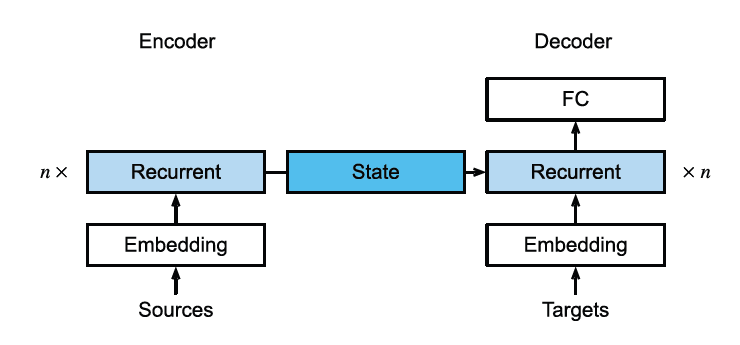

The key point of this architecture is that the encoder produces a *fixed* representation (a *context*) of the input sequence, which is then used by the decoder to produce the output. 

Let us now assume a sequence of length $T$. We will denote the hidden state of the encoder at time $t$ as $h_t$ and the decoder hidden state at time $t$ as $s_t$. We define the context at time $t$ as
$$c_t = \sum_{t = 1}^T \alpha(s_{t-1}, h_t)h_t,$$
i.e., to compute the context for the next time step, we set the decoder's current hidden state as the query, and the sequence of the encoder's hidden states
as the keys and the values. Consequently, the context is no longer *fixed*; it *evolves* as the decoder progresses with generating the output.

Overall, we get the following RNN encoder–decoder model with the *Bahdanau attention mechanism* [[1](#1), [2](#2)].

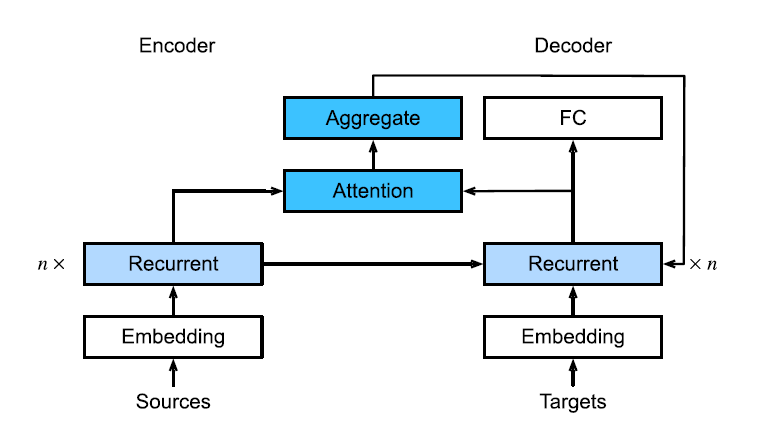

### Computations inside the Bahdanau Attention Step by Step <a class="anchor" id="step"></a>

Let us go through the computations of the encoder-decoder architecture during training. We first load in the batch.

In [44]:
for X, Y, X_len, Y_len in Tatoeba_dataset.train_dataloader:
    break

The input sequences are as follows.

In [45]:
X

tensor([[2486, 2464, 4565,  ...,   53,   53,   53],
        [2968,  689, 5066,  ...,   53,   53,   53],
        [2473, 2214,   24,  ...,   53,   53,   53],
        ...,
        [2311, 2620, 4644,  ...,   53,   53,   53],
        [4658, 4965, 3614,  ...,   53,   53,   53],
        [2612, 2464, 2848,  ...,   53,   53,   53]])

In [46]:
X.size()

torch.Size([250, 16])

In [47]:
X_len

tensor([10,  8,  4,  8, 10, 10,  9, 10, 10, 12, 13,  8,  5,  7,  6,  8,  8,  6,
         9,  9, 10,  8, 16, 13,  6, 11,  5,  5,  8,  8,  8, 12, 10, 15,  5,  7,
         8,  5,  9,  6,  9,  6, 11, 10,  7,  4,  9,  6,  6,  9,  9,  7,  8,  8,
         8, 16,  8, 10,  9,  7,  7, 12,  8,  8,  9,  4,  7,  6, 11,  8,  8,  8,
         8,  7,  8,  7,  6,  8,  5,  7,  8,  9,  6,  5,  6,  9,  8,  5,  5,  9,
        13,  7,  6,  7,  7, 10,  7,  8,  6, 12,  8,  6,  6,  5,  9,  8,  8, 11,
         8,  8,  7, 12,  7,  7,  7,  7, 11,  6,  9,  5, 10,  5,  8,  6,  9,  5,
         6,  9,  7,  6,  4, 12,  9,  5,  9,  8, 11,  8, 14,  9, 10,  7,  7,  6,
        11,  5, 10,  7,  8, 14,  7, 12,  8,  7,  8,  6,  6,  6,  5,  5,  8,  9,
         6,  7, 10, 13, 10, 11,  9,  7, 11,  9,  6,  8,  5,  9,  9,  7,  6,  7,
         8, 10,  7,  8,  9,  7,  5,  7,  7, 12,  8,  9,  8, 10,  9,  5,  6,  7,
         7,  9,  8,  6,  8,  5,  7,  6,  6,  6, 11,  7,  6,  8,  9, 12,  7,  6,
         7, 10,  9,  9, 14,  7,  9,  7, 

In [48]:
X_len.size()

torch.Size([250])

Next, we implement an RNN encoder that processes the input sequences and returns the encoder outputs and the encoder's last hidden state. 

In [49]:
class Encoder(nn.Module): 
  
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout = 0):
        super().__init__()

        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, hidden_size, num_layers, dropout = dropout)

    def forward(self, inputs):

        state = torch.zeros((self.num_layers, inputs.shape[0], self.hidden_size), device = inputs.device) 
        embeddings = self.embedding(inputs.T)
        
        outputs, state = self.rnn(embeddings, state)
        
        return outputs, state

In [50]:
hidden_size = 256
num_layers = 2
embed_size = 128
vocab_size_1 = Tatoeba_dataset.vocab_lang_1.__len__()

encoder = Encoder(vocab_size_1, embed_size, hidden_size, num_layers, dropout = 0)
enc_outputs, hidden_state = encoder(X)

In [51]:
enc_outputs.size()

torch.Size([16, 250, 256])

In [52]:
hidden_state.size()

torch.Size([2, 250, 256])

Since we are in the training regime, the decoder's input sequence is the target sequence (excluding the last element). We first need to encode the target sequences via another embedding layer.

In [53]:
vocab_size_2 = Tatoeba_dataset.vocab_lang_2.__len__()
Y_embedding = nn.Embedding(vocab_size_2, embed_size)

In [54]:
Y.size()

torch.Size([250, 17])

In [55]:
Y_embeddings = Y_embedding(Y[:,:-1].T)
Y_embeddings.size()

torch.Size([16, 250, 128])

The evaluation of the decoder's recurrent block is a bit more involved, since the context dynamically changes during the evaluation. Thus, we need to implement a custom loop. Let us perform the first iteration. The first query is the initial hidden state of the decoder (namely, we will use the hidden state of the last recurrent layer), and similar to our original implementation of the encoder-decoder architecture, we use the last encoder's hidden state as the initial hidden state of the decoder (we assume that both the encoder and the decoder has the same architecture).

In [56]:
hidden_state[1]

tensor([[ 0.0864, -0.3360, -0.2071,  ...,  0.0853, -0.2247, -0.0783],
        [ 0.1015, -0.3560, -0.2307,  ...,  0.0920, -0.2184, -0.0646],
        [ 0.1109, -0.3546, -0.2381,  ...,  0.0992, -0.2172, -0.0733],
        ...,
        [ 0.1013, -0.3559, -0.2275,  ...,  0.0894, -0.2247, -0.0785],
        [ 0.1102, -0.3546, -0.2327,  ...,  0.0961, -0.2187, -0.0760],
        [ 0.1115, -0.3554, -0.2355,  ...,  0.1002, -0.2173, -0.0730]],
       grad_fn=<SelectBackward0>)

We need to reshape this tensor slightly to match our implementation of the attention models.

In [57]:
torch.unsqueeze(hidden_state[-1], dim=1)

tensor([[[ 0.0864, -0.3360, -0.2071,  ...,  0.0853, -0.2247, -0.0783]],

        [[ 0.1015, -0.3560, -0.2307,  ...,  0.0920, -0.2184, -0.0646]],

        [[ 0.1109, -0.3546, -0.2381,  ...,  0.0992, -0.2172, -0.0733]],

        ...,

        [[ 0.1013, -0.3559, -0.2275,  ...,  0.0894, -0.2247, -0.0785]],

        [[ 0.1102, -0.3546, -0.2327,  ...,  0.0961, -0.2187, -0.0760]],

        [[ 0.1115, -0.3554, -0.2355,  ...,  0.1002, -0.2173, -0.0730]]],
       grad_fn=<UnsqueezeBackward0>)

In [58]:
query = torch.unsqueeze(hidden_state[-1], dim=1)
query.size()

torch.Size([250, 1, 256])

As we mentioned earlier, we use the encoders' outputs as both keys and values and compute the attention values, which will serve as the decoder's *context*. We will use additive attention in this implementation. Again, we need to correctly identify the dimensions of the encoder's output and the corresponding dimensions of the keys/values. The length of the input sequence (which equals the length of the encoder's output sequence) corresponds to the number of keys, and the *hidden_size* (i.e., the number of hidden states in a recurrent layer) corresponds to the dimensionality of the individual key $k_d$. In other words, each individual key corresponds to a hidden state (of the last recurrent layer).

In [59]:
enc_outputs.size()
# (input_seq_length, batch_size, hidden_size); additive attention assumes (batch_size, number of keys, k_d) = (batch_size, input_seq_length, hidden_size)

torch.Size([16, 250, 256])

In [60]:
attention = AdditiveAttention(hidden_size, dropout = 0)
context = attention(query, enc_outputs.permute(1, 0, 2), enc_outputs.permute(1, 0, 2), valid_lens = X_len)
context

tensor([[[-0.0040,  0.1642, -0.0851,  ...,  0.1476,  0.1156,  0.0469]],

        [[-0.0468,  0.0752, -0.0701,  ..., -0.0197,  0.0188,  0.1024]],

        [[-0.0558,  0.0022, -0.0516,  ..., -0.0141,  0.0109, -0.0547]],

        ...,

        [[ 0.0426,  0.0608, -0.0872,  ..., -0.0270, -0.0299, -0.0462]],

        [[ 0.0264,  0.0793, -0.0036,  ..., -0.0563,  0.0437, -0.0152]],

        [[-0.0374,  0.0283, -0.1120,  ..., -0.0040,  0.0736, -0.0212]]],
       grad_fn=<BmmBackward0>)

In [61]:
query.size()

torch.Size([250, 1, 256])

In [62]:
context.size()

torch.Size([250, 1, 256])

Lastly, the decoder's input is a concatenation of the first element of the embedded target sequence and the context from the attention model.

In [63]:
y = Y_embeddings[0]
y

tensor([[-1.2274,  1.4675, -0.5647,  ..., -0.1508,  0.8530, -0.0106],
        [-1.2274,  1.4675, -0.5647,  ..., -0.1508,  0.8530, -0.0106],
        [-1.2274,  1.4675, -0.5647,  ..., -0.1508,  0.8530, -0.0106],
        ...,
        [-1.2274,  1.4675, -0.5647,  ..., -0.1508,  0.8530, -0.0106],
        [-1.2274,  1.4675, -0.5647,  ..., -0.1508,  0.8530, -0.0106],
        [-1.2274,  1.4675, -0.5647,  ..., -0.1508,  0.8530, -0.0106]],
       grad_fn=<SelectBackward0>)

In [64]:
y.size()

torch.Size([250, 128])

In [65]:
context_y = torch.cat((context, torch.unsqueeze(y, dim=1)), dim=-1)
context_y

tensor([[[-0.0040,  0.1642, -0.0851,  ..., -0.1508,  0.8530, -0.0106]],

        [[-0.0468,  0.0752, -0.0701,  ..., -0.1508,  0.8530, -0.0106]],

        [[-0.0558,  0.0022, -0.0516,  ..., -0.1508,  0.8530, -0.0106]],

        ...,

        [[ 0.0426,  0.0608, -0.0872,  ..., -0.1508,  0.8530, -0.0106]],

        [[ 0.0264,  0.0793, -0.0036,  ..., -0.1508,  0.8530, -0.0106]],

        [[-0.0374,  0.0283, -0.1120,  ..., -0.1508,  0.8530, -0.0106]]],
       grad_fn=<CatBackward0>)

In [66]:
context_y.size()

torch.Size([250, 1, 384])

In [67]:
rnn = nn.GRU(embed_size + hidden_size, hidden_size, num_layers, dropout = 0)

The output from the decoder's recurrent block is the first element of the input for the final linear layer and the new values of the hidden states.

In [68]:
dec_output, hidden_state = rnn(context_y.permute(1, 0, 2), hidden_state)
dec_output

tensor([[[ 0.0252, -0.2539, -0.1250,  ...,  0.0629, -0.1676,  0.0617],
         [ 0.0370, -0.2722, -0.1377,  ...,  0.0633, -0.1658,  0.0736],
         [ 0.0312, -0.2761, -0.1525,  ...,  0.0701, -0.1714,  0.0692],
         ...,
         [ 0.0339, -0.2685, -0.1438,  ...,  0.0548, -0.1727,  0.0680],
         [ 0.0357, -0.2769, -0.1486,  ...,  0.0662, -0.1752,  0.0686],
         [ 0.0315, -0.2767, -0.1438,  ...,  0.0603, -0.1786,  0.0783]]],
       grad_fn=<StackBackward0>)

In [69]:
hidden_state

tensor([[[ 0.0960, -0.4911,  0.2489,  ..., -0.1452, -0.4601, -0.3994],
         [ 0.0655, -0.4883,  0.2646,  ..., -0.1605, -0.4512, -0.4042],
         [ 0.1184, -0.5031,  0.2487,  ..., -0.1533, -0.4619, -0.4037],
         ...,
         [ 0.1225, -0.4920,  0.2582,  ..., -0.1485, -0.4488, -0.3965],
         [ 0.0804, -0.4588,  0.2456,  ..., -0.1393, -0.4493, -0.4042],
         [ 0.1173, -0.5035,  0.2440,  ..., -0.1555, -0.4497, -0.3875]],

        [[ 0.0252, -0.2539, -0.1250,  ...,  0.0629, -0.1676,  0.0617],
         [ 0.0370, -0.2722, -0.1377,  ...,  0.0633, -0.1658,  0.0736],
         [ 0.0312, -0.2761, -0.1525,  ...,  0.0701, -0.1714,  0.0692],
         ...,
         [ 0.0339, -0.2685, -0.1438,  ...,  0.0548, -0.1727,  0.0680],
         [ 0.0357, -0.2769, -0.1486,  ...,  0.0662, -0.1752,  0.0686],
         [ 0.0315, -0.2767, -0.1438,  ...,  0.0603, -0.1786,  0.0783]]],
       grad_fn=<StackBackward0>)

The steps inside the loop end here, and we would now repeat these steps (update the context, compute the second element of the decoder's output, and the new hidden state ... ) until we have processed the whole sequence in *Y*. Overall, we obtain the following decoder implementation with attention [[2](#2)].  

In [70]:
class Attention_decoder(nn.Module): 
  
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout = 0):
        super().__init__()

        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.attention = AdditiveAttention(hidden_size, dropout)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size + hidden_size, hidden_size, num_layers, dropout = dropout)
        self.linear = nn.Linear(hidden_size, vocab_size)

    def forward(self, inputs, states):
        
        hidden_state, enc_output, valid_len = states

        embeddings = self.embedding(inputs.T)
        dec_output, self._attention_weights = [], []
        
        for y in embeddings:
            query = torch.unsqueeze(hidden_state[-1], dim=1) # query: (batch_size, 1, num_hiddens)
            context = self.attention(query, enc_output.permute(1, 0, 2), enc_output.permute(1, 0, 2), valid_len) #context: (batch_size, 1, num_hiddens)
            context_y = torch.cat((context, torch.unsqueeze(y, dim=1)), dim=-1) #concat inputs and context 
            output, hidden_state = self.rnn(context_y.permute(1, 0, 2), hidden_state)
            
            dec_output.append(output)
            self._attention_weights.append(self.attention.attention_weights)


        outputs = self.linear(torch.cat(dec_output, dim=0))
        
        return outputs, [enc_output, hidden_state, valid_len]

Putting the encoder and the decoder together is quite straightforward.

In [71]:
class Encoder_Attention_decoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout = 0):
        super().__init__()

        self.encoder = Encoder(vocab_size[0], embed_size, hidden_size, num_layers, dropout = dropout)
        self.decoder = Attention_decoder(vocab_size[1], embed_size, hidden_size, num_layers, dropout = dropout)

    def forward(self, input_X, input_Y, X_len):
        
        enc_output, hidden_state = self.encoder(input_X)
        dec_output, _ = self.decoder(input_Y, [hidden_state, enc_output, X_len]) 

        return dec_output

We can check the overall architecture evaluation.

In [72]:
hidden_size = 256
num_layers = 2
embed_size = 128
vocab_size_1 = Tatoeba_dataset.vocab_lang_1.__len__()
vocab_size_2 = Tatoeba_dataset.vocab_lang_2.__len__()

encoder_decoder = Encoder_Attention_decoder([vocab_size_1, vocab_size_2], embed_size, hidden_size, num_layers)

output = encoder_decoder(X, Y[:,:-1], X_len)
output

tensor([[[ 0.1565, -0.0359, -0.1099,  ...,  0.1595, -0.0206,  0.0069],
         [ 0.1582, -0.0418, -0.1112,  ...,  0.1550, -0.0268,  0.0009],
         [ 0.1547, -0.0395, -0.1126,  ...,  0.1547, -0.0275,  0.0011],
         ...,
         [ 0.1484, -0.0369, -0.1096,  ...,  0.1567, -0.0242,  0.0061],
         [ 0.1606, -0.0380, -0.1130,  ...,  0.1523, -0.0305,  0.0054],
         [ 0.1583, -0.0334, -0.1090,  ...,  0.1548, -0.0269, -0.0027]],

        [[ 0.1325, -0.0094, -0.0804,  ...,  0.1934,  0.0013,  0.0234],
         [ 0.1158, -0.0843, -0.1269,  ...,  0.2157,  0.0123,  0.0736],
         [ 0.1736, -0.0334, -0.1070,  ...,  0.0778,  0.0131,  0.0654],
         ...,
         [ 0.0807, -0.0262, -0.0908,  ...,  0.1826,  0.0141,  0.0125],
         [ 0.1422, -0.0411, -0.1093,  ...,  0.1689, -0.0840,  0.0367],
         [ 0.1470,  0.0019, -0.0545,  ...,  0.0907, -0.0481,  0.0254]],

        [[ 0.1328, -0.0400, -0.0805,  ...,  0.1559,  0.0348,  0.0493],
         [ 0.0232, -0.1223, -0.0873,  ...,  0

In [73]:
output.size()

torch.Size([16, 250, 9634])

Lastly, we can compute the (masked) cross-entropy loss as usual.

In [74]:
def masked_loss(loss, Y_hat, Y, Y_len):
    
    loss_all = cross_entropy_loss(Y_hat, Y[:,1:])
    loss = 0

    for i in range(loss_all.size()[0]):
        loss = loss + (loss_all[i][:Y_len[i]]).mean()

    return loss/len(Y)

In [75]:
cross_entropy_loss = nn.CrossEntropyLoss(reduction='none')
loss = masked_loss(cross_entropy_loss, output.permute(1, 2, 0), Y, Y_len)
loss

tensor(9.1729, grad_fn=<DivBackward0>)

## Training Encoder-Decoder Model with the Bahdanau Attention  <a class="anchor" id="train"></a>

We are now ready to put together the training loop.

In [76]:
def train_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler, max_norm):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    size_train = 0

    
    for batch, (X, Y, X_len, Y_len) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        Y = Y.to(cuda_device)
        X_len = X_len.to(cuda_device)
        Y_len = Y_len.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits = model(X, Y[:,:-1], X_len) # forward pass
        loss = masked_loss(loss_fn, pred_logits.permute(1, 2, 0), Y, Y_len) # loss evaluation 
        #loss = loss_fn(pred_logits.permute(1, 2, 0), Y[:,1:]) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = max_norm) # gradient clipping
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
           
    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        size_test = 0
        
        for batch, (X_test, Y_test, X_len_test, Y_len_test) in enumerate(test_data_loader):

            state = None
            X_test = X_test.to(cuda_device)
            Y_test = Y_test.to(cuda_device)
            X_len_test = X_len_test.to(cuda_device)
            Y_len_test = Y_len_test.to(cuda_device)
            
            pred_logits_test = model(X_test, Y_test[:,:-1], X_len_test)
            
            loss_sum_test = loss_sum_test + masked_loss(loss_fn, pred_logits_test.permute(1, 2, 0), Y_test, Y_len_test)*len(X_test)
            #loss_sum_test = loss_sum_test + loss_fn(pred_logits_test.permute(1, 2, 0), Y_test[:,1:])*len(X_test)

            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0]

Let us train the model on the Tatoeba dataset (consisting of the English-Czech sentence pairs).

In [77]:
torch.manual_seed(123)

# data loader
Tatoeba_dataset = Tatoeba('D:/nine circles 2/ces.txt', num_train = 38000, batch_size = 250, max_length = 15) 
Tatoeba_train_loader = Tatoeba_dataset.train_dataloader
Tatoeba_test_loader = Tatoeba_dataset.test_dataloader

hidden_size = 256
num_layers = 2
vocab_size_1 = Tatoeba_dataset.vocab_lang_1.__len__()
vocab_size_2 = Tatoeba_dataset.vocab_lang_2.__len__()
embed_size = 256

encoder_decoder_cuda = Encoder_Attention_decoder(hidden_size = hidden_size, num_layers = num_layers, vocab_size = [vocab_size_1, vocab_size_2], embed_size = 100).to(cuda_device)

optim_SGD_cuda =  torch.optim.SGD(encoder_decoder_cuda.parameters(), lr = 0.1, momentum = 0.9, weight_decay = 0.0001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[200], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(reduction='none')
max_norm = 10

n_epochs = 300

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t]   = train_test_loop_cuda(Tatoeba_train_loader, Tatoeba_test_loader, encoder_decoder_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

5190.641100883484


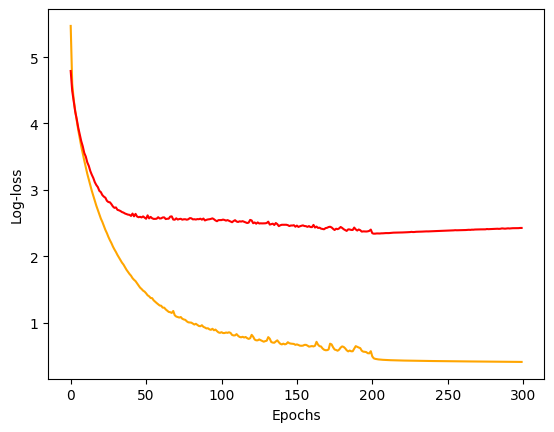

In [78]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

In [79]:
loss_epochs_train[299]

0.40697792172431946

In [80]:
loss_epochs_test[299]

2.425764322280884

In [81]:
loss_epochs_test.min()

2.3395259380340576

In terms of loss, we achieved values similar to those of our encoder-decoder model with fixed context. Let us check the BLEU score of the predictions. Again, we can use either the greedy or beam search strategy. The implementation of both of these is very similar to the one we used in our first encoder-decoder project. Let us start with greedy predictions.

In [82]:
def predict_greedy(model, input_X, input_Y_init, X_len, num_steps):

        input_Y = input_Y_init
        prefix = input_Y_init
        enc_output, hidden_state = model.encoder(input_X)
        
        for i in range(num_steps): 

            output, states = model.decoder(input_Y, [hidden_state, enc_output, X_len])
            hidden_state = states[1]
            input_Y = output.argmax()[None][None]
            prefix = torch.cat((prefix,input_Y),0)

        return prefix.flatten()

In [83]:
for X, Y, X_len, Y_len in Tatoeba_dataset.test_dataloader:
    break

In [84]:
bos_token = torch.tensor(Tatoeba_dataset.vocab_lang_2['<bos>'])
bos_token = bos_token[None][None]

greedy_pred = predict_greedy(encoder_decoder_cuda, X[0][None,:].to(cuda_device), bos_token.to(cuda_device), X_len[0].to(cuda_device), 10)
Tatoeba_dataset.vocab_lang_2.to_tokens(greedy_pred)

['<bos>', 'nic', 'o', 'nic', 'nevím', '.', '<eos>', '.', '<eos>', '<eos>', '.']

In [85]:
Tatoeba_dataset.vocab_lang_2.to_tokens(Y[0])[1:Y_len[0]]

['o', 'ničem', 'nic', 'nevím', '.']

This is actually the same translation of "I don't know anything about anything" we have obtained from our best models in the past.

In [86]:
greedy_pred = predict_greedy(encoder_decoder_cuda, X[3][None,:].to(cuda_device), bos_token.to(cuda_device), X_len[3].to(cuda_device), 10)
Tatoeba_dataset.vocab_lang_2.to_tokens(greedy_pred)

['<bos>',
 'kéž',
 'bych',
 'mohl',
 'jít',
 's',
 'tebou',
 '.',
 '<eos>',
 '.',
 '<eos>']

In [87]:
Tatoeba_dataset.vocab_lang_2.to_tokens(Y[3])[1:Y_len[3]]

['kéž', 'bych', 'byl', 'šel', 's', 'tebou', '.']

In [88]:
Tatoeba_dataset.vocab_lang_1.to_tokens(X[3])[1:X_len[3]]

['wish', 'i', "could've", 'gone', 'with', 'you', '.', '<eos>']

Actually, this translation of  "I wish I could've gone with you" is pretty impressive. It is worded differently from the target sequence, but both translations are correct (I actually find the machine translation a bit more natural; the original target sentence is a bit bookish). We should remember that in our previous non-attention models, the best translations were shifted from "I wish I could have gone with you" to "I wish I could have been with you." 

Let us have a look at the beam search predictions next.

In [89]:
def predict_beam(model, input_X, input_Y_init, X_len, num_steps, beam_size):

        with torch.no_grad():
            
            input_Y = input_Y_init
            prefix = input_Y_init
            enc_output , hidden_state = model.encoder(input_X)
    
            output, state = model.decoder(input_Y, [hidden_state, enc_output, X_len])
            hidden_state = state[1]

            sort_by_prob = torch.sort(torch.nn.functional.softmax(output.flatten(), dim = 0),descending  = True)
                
            # predicted sequences
            pred_token_seq = torch.zeros([beam_size, num_steps], device = input_X.device).long() 
            pred_token_seq[:,0] = sort_by_prob[1][:beam_size]

            # probabilities
            prob_seq = sort_by_prob[0][:beam_size]

            # hidden states             
            hidden_states_seq = hidden_state.repeat([1,beam_size,1])
            enc_output_seq = enc_output.repeat([1,beam_size,1])
            X_len_seq = X_len.repeat([1,beam_size,1])
            
            for i in range(1, num_steps):
            
                outputs, states = model.decoder(pred_token_seq[:,i-1].reshape([beam_size,1]), [hidden_states_seq, enc_output_seq, X_len_seq])
                hidden_states = states[1]

                pred_token_seq_new = torch.zeros([beam_size, num_steps], device = input_X.device).long() 

                output_0_sort_by_prob = torch.sort(torch.nn.functional.softmax(outputs[:,0,:].flatten(), dim = 0),descending  = True)

                pred_token_seq_new[:,0:i] =  pred_token_seq[0,0:i]
                pred_token_seq_new[:,i] = output_0_sort_by_prob[1][:beam_size]
                
                prob_seq_new = prob_seq[0]*output_0_sort_by_prob[0][:beam_size]
                hidden_states_seq = hidden_states[:,0,:][:,None,:].repeat([1,beam_size,1])

                for j in range(1, beam_size):
                
                    output_j_sort_by_prob = torch.sort(torch.nn.functional.softmax(outputs[:,j,:].flatten(), dim = 0),descending  = True)

                    for k in range(beam_size):

                        prob_cand = prob_seq[j]*output_j_sort_by_prob[0][k]
                    
                        for l in range(beam_size):
                        
                            if prob_cand > prob_seq_new[l]:
                                prob_seq_new[l] = prob_cand
                                pred_token_seq_new[l,0:i] = pred_token_seq[j,0:i]
                                pred_token_seq_new[l,i] = output_j_sort_by_prob[1][k]
                                hidden_states_seq[:,l,:] = hidden_states[:,j,:]
                                break

                        if (l == beam_size):
                            break
                            
                prob_seq = prob_seq_new
                pred_token_seq = pred_token_seq_new
                
        # return outputs, states
        return pred_token_seq, prob_seq 

In [90]:
pred_token_seq, prob_pred = predict_beam(encoder_decoder_cuda, X[0][None,:].to(cuda_device), bos_token.to(cuda_device), X_len[0].to(cuda_device), num_steps = 10, beam_size = 10)
Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])

['nic', 'o', 'nic', 'nevím', '.', '<eos>', '.', '<eos>', '<eos>', '.']

In [91]:
pred_token_seq, prob_pred = predict_beam(encoder_decoder_cuda, X[3][None,:].to(cuda_device), bos_token.to(cuda_device), X_len[3].to(cuda_device), num_steps = 10, beam_size = 10)
Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])

['kéž', 'bych', 'mohl', 'jít', 's', 'tebou', '.', '<eos>', '.', '<eos>']

Unsurprisingly, since the greedy search performed well, the beam search also did fine on these two sequences. Let us move beyond these anecdotal examples and compare the performance systematically. We will again define the BLEU score and compare the results on the test set.

In [92]:
def BLEU(pred_tokens, label_tokens, k): 

    len_pred, len_label = len(pred_tokens), len(label_tokens)
    score = math.exp(min(0, 1 - len_label / len_pred))
    
    for n in range(1, min(k, len_pred) + 1):
        num_matches, label_subs = 0, collections.defaultdict(int)
        for i in range(len_label - n + 1):
            label_subs[' '.join(label_tokens[i: i + n])] += 1
        for i in range(len_pred - n + 1):
            if label_subs[' '.join(pred_tokens[i: i + n])] > 0:
                num_matches += 1
                label_subs[' '.join(pred_tokens[i: i + n])] -= 1
    score *= math.pow(num_matches / (len_pred - n + 1), math.pow(0.5, n))
    return score

In [93]:
bleu_score = []

for X, Y, X_len, Y_len in Tatoeba_dataset.test_dataloader:
    
    for i in range(len(X)):
        
        pred_token_seq = predict_greedy(encoder_decoder_cuda, X[i][None,:].to(cuda_device), bos_token.to(cuda_device), X_len[i].to(cuda_device), num_steps = 15)
        pred_token_seq = Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq)
        
        try:
            idx = pred_token_seq.index('<eos>')
        except:
            idx = len(pred_token_seq)
            
        pred_token_seq = pred_token_seq[:idx]
        if len(pred_token_seq) > 0:
            bleu_score.append(BLEU(pred_token_seq, Tatoeba_dataset.vocab_lang_2.to_tokens(Y[i][1:Y_len[i]]), 3))
        else:
            bleu_score.append(0)

In [94]:
sum(bleu_score)/len(bleu_score)

0.3167374450101417

In [95]:
bleu_score = []

for X, Y, X_len, Y_len in Tatoeba_dataset.test_dataloader:
    
    for i in range(len(X)):
        
        pred_token_seq, _ = predict_beam(encoder_decoder_cuda, X[i][None,:].to(cuda_device), bos_token.to(cuda_device), X_len[i].to(cuda_device), num_steps = 15, beam_size = 5)
        pred_token_seq = Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])
        
        try:
            idx = pred_token_seq.index('<eos>')
        except:
            idx = len(pred_token_seq)
            
        pred_token_seq = pred_token_seq[:idx]
        if len(pred_token_seq) > 0:
            bleu_score.append(BLEU(pred_token_seq, Tatoeba_dataset.vocab_lang_2.to_tokens(Y[i][1:Y_len[i]]), 3))
        else:
            bleu_score.append(0)

In [96]:
sum(bleu_score)/len(bleu_score)

0.3202452213476517

First off, the BLEU score for the encoder-decoder model with attention is about 0.05 higher than for our models without attention. In addition, we observe that beam search is slightly better than greedy search, as expected. 

In the previous model, we used an additive attention model. Let us now try a dot-product model.

In [97]:
class Attention_decoder2(nn.Module): 
  
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout = 0):
        super().__init__()

        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.attention = DotProductAttention(dropout)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size + hidden_size, hidden_size, num_layers, dropout = dropout)
        self.linear = nn.Linear(hidden_size, vocab_size)

    def forward(self, inputs, states):
        
        hidden_state, enc_output, valid_len = states

        embeddings = self.embedding(inputs.T)
        dec_output, self._attention_weights = [], []
        
        for y in embeddings:
            query = torch.unsqueeze(hidden_state[-1], dim=1) # query: (batch_size, 1, num_hiddens)
            context = self.attention(query, enc_output.permute(1, 0, 2), enc_output.permute(1, 0, 2), valid_len) #context: (batch_size, 1, num_hiddens)
            context_y = torch.cat((context, torch.unsqueeze(y, dim=1)), dim=-1) #concat inputs and context 
            output, hidden_state = self.rnn(context_y.permute(1, 0, 2), hidden_state)
            
            dec_output.append(output)
            self._attention_weights.append(self.attention.attention_weights)


        outputs = self.linear(torch.cat(dec_output, dim=0))
        
        return outputs, [enc_output, hidden_state, valid_len]

In [98]:
class Encoder_Attention_decoder2(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout = 0):
        super().__init__()

        self.encoder = Encoder(vocab_size[0], embed_size, hidden_size, num_layers, dropout = dropout)
        self.decoder = Attention_decoder2(vocab_size[1], embed_size, hidden_size, num_layers, dropout = dropout)

    def forward(self, input_X, input_Y, X_len):
        
        enc_output, hidden_state = self.encoder(input_X)
        dec_output, _ = self.decoder(input_Y, [hidden_state, enc_output, X_len]) 

        return dec_output

In [99]:
torch.manual_seed(123)

# data loader
Tatoeba_dataset = Tatoeba('D:/nine circles 2/ces.txt', num_train = 38000, batch_size = 250, max_length = 15) 
Tatoeba_train_loader = Tatoeba_dataset.train_dataloader
Tatoeba_test_loader = Tatoeba_dataset.test_dataloader

hidden_size = 256
num_layers = 2
vocab_size_1 = Tatoeba_dataset.vocab_lang_1.__len__()
vocab_size_2 = Tatoeba_dataset.vocab_lang_2.__len__()
embed_size = 256

encoder_decoder_cuda = Encoder_Attention_decoder2(hidden_size = hidden_size, num_layers = num_layers, vocab_size = [vocab_size_1, vocab_size_2], embed_size = 100).to(cuda_device)

optim_SGD_cuda =  torch.optim.SGD(encoder_decoder_cuda.parameters(), lr = 0.1, momentum = 0.9, weight_decay = 0.0001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[200], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(reduction='none')
max_norm = 10

n_epochs = 300

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t]   = train_test_loop_cuda(Tatoeba_train_loader, Tatoeba_test_loader, encoder_decoder_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

4864.453296422958


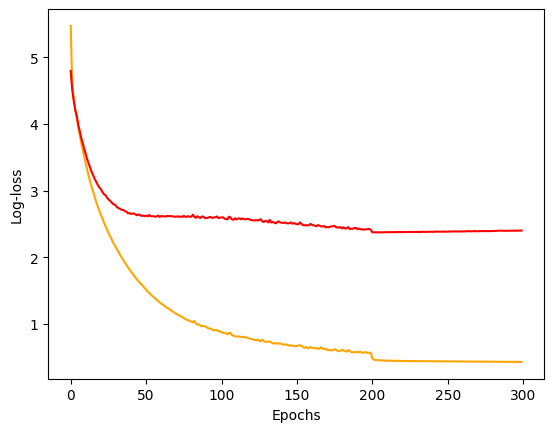

In [100]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

In [101]:
loss_epochs_train[299]

0.4302980303764343

In [102]:
loss_epochs_test[299]

2.401031494140625

In [103]:
loss_epochs_test.min()

2.3733725547790527

The log-loss is again quite similar. Let us check the BLEU score.

In [104]:
bleu_score = []

for X, Y, X_len, Y_len in Tatoeba_dataset.test_dataloader:
    
    for i in range(len(X)):
        
        pred_token_seq = predict_greedy(encoder_decoder_cuda, X[i][None,:].to(cuda_device), bos_token.to(cuda_device), X_len[i].to(cuda_device), num_steps = 15)
        pred_token_seq = Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq)
        
        try:
            idx = pred_token_seq.index('<eos>')
        except:
            idx = len(pred_token_seq)
            
        pred_token_seq = pred_token_seq[:idx]
        if len(pred_token_seq) > 0:
            bleu_score.append(BLEU(pred_token_seq, Tatoeba_dataset.vocab_lang_2.to_tokens(Y[i][1:Y_len[i]]), 3))
        else:
            bleu_score.append(0)

In [105]:
sum(bleu_score)/len(bleu_score)

0.29041685176818627

In [106]:
bleu_score = []

for X, Y, X_len, Y_len in Tatoeba_dataset.test_dataloader:
    
    for i in range(len(X)):
        
        pred_token_seq, _ = predict_beam(encoder_decoder_cuda, X[i][None,:].to(cuda_device), bos_token.to(cuda_device), X_len[i].to(cuda_device), num_steps = 15, beam_size = 5)
        pred_token_seq = Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])
        
        try:
            idx = pred_token_seq.index('<eos>')
        except:
            idx = len(pred_token_seq)
            
        pred_token_seq = pred_token_seq[:idx]
        if len(pred_token_seq) > 0:
            bleu_score.append(BLEU(pred_token_seq, Tatoeba_dataset.vocab_lang_2.to_tokens(Y[i][1:Y_len[i]]), 3))
        else:
            bleu_score.append(0)

In [107]:
sum(bleu_score)/len(bleu_score)

0.29955274944277044

The encoder-decoder with the dot-product attention seems slightly worse.

As the final step of this project, let us move to the dataset of English-French sentence pairs.

In [108]:
torch.manual_seed(123)

# data loader
Tatoeba_dataset = Tatoeba('D:/nine circles 2/fra.txt', num_train = 220000, batch_size = 250, max_length = 15) 
Tatoeba_train_loader = Tatoeba_dataset.train_dataloader
Tatoeba_test_loader = Tatoeba_dataset.test_dataloader

hidden_size = 256
num_layers = 2
vocab_size_1 = Tatoeba_dataset.vocab_lang_1.__len__()
vocab_size_2 = Tatoeba_dataset.vocab_lang_2.__len__()
embed_size = 256

encoder_decoder_cuda = Encoder_Attention_decoder(hidden_size = hidden_size, num_layers = num_layers, vocab_size = [vocab_size_1, vocab_size_2], embed_size = 100).to(cuda_device)

optim_SGD_cuda =  torch.optim.SGD(encoder_decoder_cuda.parameters(), lr = 0.1, momentum = 0.9, weight_decay = 0.0001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[150], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(reduction='none')
max_norm = 10

n_epochs = 200

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t]   = train_test_loop_cuda(Tatoeba_train_loader, Tatoeba_test_loader, encoder_decoder_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

20757.83196592331


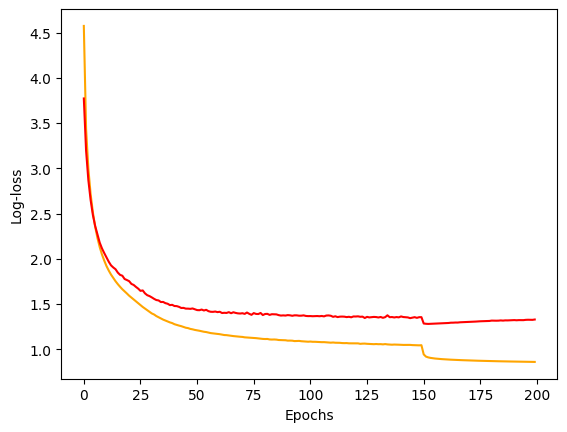

In [109]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

In [110]:
loss_epochs_train[9]

1.9798016548156738

In [111]:
loss_epochs_test[9]

2.0627458095550537

In [112]:
loss_epochs_test.min()

1.278843879699707

In [113]:
bleu_score = []

for X, Y, X_len, Y_len in Tatoeba_dataset.test_dataloader:
    
    for i in range(len(X)):
        
        pred_token_seq = predict_greedy(encoder_decoder_cuda, X[i][None,:].to(cuda_device), bos_token.to(cuda_device), X_len[i].to(cuda_device), num_steps = 15)
        pred_token_seq = Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq)
        
        try:
            idx = pred_token_seq.index('<eos>')
        except:
            idx = len(pred_token_seq)
            
        pred_token_seq = pred_token_seq[:idx]
        if len(pred_token_seq) > 0:
            bleu_score.append(BLEU(pred_token_seq, Tatoeba_dataset.vocab_lang_2.to_tokens(Y[i][1:Y_len[i]]), 3))
        else:
            bleu_score.append(0)

In [114]:
sum(bleu_score)/len(bleu_score)

0.559295960333002

In [115]:
bleu_score = []

for X, Y, X_len, Y_len in Tatoeba_dataset.test_dataloader:
    
    for i in range(len(X)):
        
        pred_token_seq, _ = predict_beam(encoder_decoder_cuda, X[i][None,:].to(cuda_device), bos_token.to(cuda_device), X_len[i].to(cuda_device), num_steps = 15, beam_size = 5)
        pred_token_seq = Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])
        
        try:
            idx = pred_token_seq.index('<eos>')
        except:
            idx = len(pred_token_seq)
            
        pred_token_seq = pred_token_seq[:idx]
        if len(pred_token_seq) > 0:
            bleu_score.append(BLEU(pred_token_seq, Tatoeba_dataset.vocab_lang_2.to_tokens(Y[i][1:Y_len[i]]), 3))
        else:
            bleu_score.append(0)

In [116]:
sum(bleu_score)/len(bleu_score)

0.5697814784109092

Again, the RNN encoder-decoder with attention is significantly better than the one we obtained by using a purely RNN design. 

Overall, we have learned that the attention mechanism improves the performance of the RNN encoder-decoder design, which was the original motivation for introducing it in the first place. However, it later turned out that we can use attention-based architectures for sequence modeling tasks without any recurrent elements and adopt a feedforward *transformer* design instead. This paradigm shift mainly enabled easier parallelization (which is inherently more difficult in RNNs due to their sequential nature), allowing researchers and tech companies to train bigger and bigger *large language models*. Indeed, *attention was all that was needed*.

## References <a class="anchor" id="references"></a>

<a id="1">[1]</a> BAHDANAU, Dzmitry; CHO, Kyunghyun; BENGIO, Yoshua. Neural machine translation by jointly learning to align and translate. *arXiv preprint arXiv:1409.0473*, 2014.

<a id="2">[2]</a> ZHANG, Aston, et al. *Dive into deep learning*. Cambridge University Press, 2023.

<a id="3">[3]</a> GIVENS, Geof H.; HOETING, Jennifer A. *Computational statistics.* John Wiley & Sons, 2012.
